# Comprehensive Descriptive Statistics

This notebook provides a comprehensive analysis of the newsData dataset, covering:
- Dataset overview and basic statistics
- Headline analysis and character count distribution
- Publisher activity analysis and market concentration
- Stock coverage analysis
- Temporal patterns and trends
- Word frequency analysis
- Visualizations and insights

## 1. Import Libraries and Load Data

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from datetime import datetime
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load and Initialize the News Data

In [ ]:
# Load the news data
data_path = '../Data/newsData/raw_analyst_ratings.csv'
try:
    df = pd.read_csv(data_path)
    print("News data loaded successfully!")
    print(f"Dataset shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print("\nFirst few rows:")
    display(df.head())
except FileNotFoundError:
    print(f"Error: Data file not found at {data_path}")
    print("Please ensure the data file exists in the correct location.")
    # Create a sample dataframe for demonstration
    df = pd.DataFrame({
        'headline': ['Sample headline 1', 'Sample headline 2', 'Sample headline 3'],
        'publisher': ['Publisher A', 'Publisher B', 'Publisher A'],
        'stock': ['AAPL', 'GOOGL', 'AAPL'],
        'date': ['2020-01-01', '2020-01-02', '2020-01-03'],
        'url': ['url1', 'url2', 'url3']
    })
    print("Created sample data for demonstration.")

News data loaded successfully!
Dataset shape: (1407328, 6)
Columns: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']

First few rows:


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


## 3. Basic Dataset Statistics

In [18]:
# Calculate basic statistics
headline_lengths = df['headline'].str.len()
publisher_counts = df['publisher'].value_counts()
stock_counts = df['stock'].value_counts()

basic_stats = {
    'dataset': {
        'total_articles': len(df),
        'unique_publishers': df['publisher'].nunique(),
        'unique_stocks': df['stock'].nunique(),
        'date_range_days': 0
    },
    'headline_length': {
        'mean': headline_lengths.mean(),
        'median': headline_lengths.median(),
        'std': headline_lengths.std(),
        'min': headline_lengths.min(),
        'max': headline_lengths.max(),
        'q25': headline_lengths.quantile(0.25),
        'q75': headline_lengths.quantile(0.75)
    },
    'publisher_stats': {
        'total_publishers': len(publisher_counts),
        'avg_articles_per_publisher': len(df) / len(publisher_counts),
        'median_articles_per_publisher': publisher_counts.median(),
        'max_articles_by_publisher': publisher_counts.max(),
        'min_articles_by_publisher': publisher_counts.min()
    },
    'stock_stats': {
        'total_stocks': len(stock_counts),
        'stocks_with_single_article': (stock_counts == 1).sum(),
        'stocks_with_multiple_articles': (stock_counts > 1).sum()
    }
}

# Calculate date range
try:
    dates = pd.to_datetime(df['date'], errors='coerce')
    valid_dates = dates.dropna()
    if len(valid_dates) > 0:
        basic_stats['dataset']['date_range_days'] = (valid_dates.max() - valid_dates.min()).days
except Exception as e:
    print(f"Date parsing error: {e}")

print("DATASET OVERVIEW:")
print("-" * 40)
dataset_stats = basic_stats['dataset']
for key, value in dataset_stats.items():
    print(f"{key.replace('_', ' ').title()}: {value:,}")

print("\nPUBLISHER OVERVIEW:")
print("-" * 40)
publisher_stats = basic_stats['publisher_stats']
for key, value in publisher_stats.items():
    if isinstance(value, float):
        print(f"{key.replace('_', ' ').title()}: {value:.2f}")
    else:
        print(f"{key.replace('_', ' ').title()}: {value:,}")

print("\nSTOCK COVERAGE OVERVIEW:")
print("-" * 40)
stock_stats = basic_stats['stock_stats']
for key, value in stock_stats.items():
    print(f"{key.replace('_', ' ').title()}: {value:,}")

print("\nHEADLINE LENGTH STATISTICS:")
print("-" * 40)
headline_stats = basic_stats['headline_length']
for key, value in headline_stats.items():
    print(f"{key.replace('_', ' ').title()}: {value:.2f}")

DATASET OVERVIEW:
----------------------------------------
Total Articles: 1,407,328
Unique Publishers: 1,034
Unique Stocks: 6,204
Date Range Days: 3,332

PUBLISHER OVERVIEW:
----------------------------------------
Total Publishers: 1,034
Avg Articles Per Publisher: 1361.05
Median Articles Per Publisher: 11.00
Max Articles By Publisher: 228,373
Min Articles By Publisher: 1

STOCK COVERAGE OVERVIEW:
----------------------------------------
Total Stocks: 6,204
Stocks With Single Article: 242
Stocks With Multiple Articles: 5,962

HEADLINE LENGTH STATISTICS:
----------------------------------------
Mean: 73.12
Median: 64.00
Std: 40.74
Min: 3.00
Max: 512.00
Q25: 47.00
Q75: 87.00


## 4. Headline Character Count Distribution

In [19]:
# Analyze headline length distribution
hist, bin_edges = np.histogram(headline_lengths, bins=30)
length_counts = headline_lengths.value_counts().head(10)

headline_dist = {
    'length_percentiles': {
        '10th': headline_lengths.quantile(0.10),
        '25th': headline_lengths.quantile(0.25),
        '50th': headline_lengths.quantile(0.50),
        '75th': headline_lengths.quantile(0.75),
        '90th': headline_lengths.quantile(0.90),
        '95th': headline_lengths.quantile(0.95),
        '99th': headline_lengths.quantile(0.99)
    },
    'most_common_lengths': length_counts.to_dict()
}

print("HEADLINE LENGTH DISTRIBUTION:")
print(f"Total headlines: {len(headline_lengths):,}")

print("\nPercentiles:")
for percentile, value in headline_dist['length_percentiles'].items():
    print(f"  {percentile}: {value:.1f} characters")

print("\nTop 10 most common headline lengths:")
for i, (length, count) in enumerate(list(headline_dist['most_common_lengths'].items())[:10]):
    print(f"  {i+1}. {length} characters ({count:,} headlines)")

HEADLINE LENGTH DISTRIBUTION:
Total headlines: 1,407,328

Percentiles:
  10th: 36.0 characters
  25th: 47.0 characters
  50th: 64.0 characters
  75th: 87.0 characters
  90th: 117.0 characters
  95th: 153.0 characters
  99th: 235.0 characters

Top 10 most common headline lengths:
  1. 47 characters (27,466 headlines)
  2. 39 characters (26,810 headlines)
  3. 48 characters (24,375 headlines)
  4. 40 characters (24,042 headlines)
  5. 49 characters (23,045 headlines)
  6. 50 characters (22,761 headlines)
  7. 56 characters (22,707 headlines)
  8. 32 characters (22,323 headlines)
  9. 44 characters (21,515 headlines)
  10. 53 characters (21,424 headlines)


## 5. Comprehensive Publisher Analysis

In [20]:
# Analyze publisher activity in detail
top_publishers = publisher_counts.head(20)
top_10_publishers = publisher_counts.head(10)
top_50_publishers = publisher_counts.head(50)

publisher_analysis = {
    'total_publishers': len(publisher_counts),
    'top_publishers': top_publishers.to_dict(),
    'publisher_percentages': (top_publishers / len(df) * 100).round(2).to_dict(),
    'concentration_ratio': {
        'top_5': (publisher_counts.head(5).sum() / len(df) * 100).round(2),
        'top_10': (publisher_counts.head(10).sum() / len(df) * 100).round(2),
        'top_20': (publisher_counts.head(20).sum() / len(df) * 100).round(2),
        'top_50': (publisher_counts.head(50).sum() / len(df) * 100).round(2)
    },
    'activity_bins': {
        '1-10 articles': ((publisher_counts >= 1) & (publisher_counts <= 10)).sum(),
        '11-50 articles': ((publisher_counts >= 11) & (publisher_counts <= 50)).sum(),
        '51-100 articles': ((publisher_counts >= 51) & (publisher_counts <= 100)).sum(),
        '101-500 articles': ((publisher_counts >= 101) & (publisher_counts <= 500)).sum(),
        '501-1000 articles': ((publisher_counts >= 501) & (publisher_counts <= 1000)).sum(),
        '1001-10000 articles': ((publisher_counts >= 1001) & (publisher_counts <= 10000)).sum(),
        '10000+ articles': (publisher_counts > 10000).sum()
    }
}

print("PUBLISHER ACTIVITY ANALYSIS:")
print(f"Total Publishers: {publisher_analysis['total_publishers']:,}")

print("\nConcentration Ratios:")
cr = publisher_analysis['concentration_ratio']
for metric, value in cr.items():
    print(f"  {metric.replace('_', ' ').title()}: {value:.1f}%")

print("\nTop 10 Most Active Publishers:")
top_pubs = list(publisher_analysis['top_publishers'].items())[:10]
for i, (publisher, count) in enumerate(top_pubs, 1):
    percentage = publisher_analysis['publisher_percentages'].get(publisher, 0)
    print(f"  {i:2d}. {publisher}: {count:,} articles ({percentage:.1f}%)")

print("\nPUBLISHER ACTIVITY DISTRIBUTION:")
print("-" * 40)
activity_bins = publisher_analysis['activity_bins']
for category, count in activity_bins.items():
    percentage = (count / publisher_analysis['total_publishers'] * 100).round(1)
    print(f"  {category}: {count} publishers ({percentage}%)")

# Calculate percentiles
percentiles = [10, 25, 50, 75, 90, 95, 99]
print("\nPublisher Activity Percentiles:")
for p in percentiles:
    value = publisher_counts.quantile(p/100)
    print(f"  {p}th percentile: {value:.0f} articles")

PUBLISHER ACTIVITY ANALYSIS:
Total Publishers: 1,034

Concentration Ratios:
  Top 5: 52.9%
  Top 10: 66.5%
  Top 20: 79.3%
  Top 50: 90.9%

Top 10 Most Active Publishers:
   1. Paul Quintaro: 228,373 articles (16.2%)
   2. Lisa Levin: 186,979 articles (13.3%)
   3. Benzinga Newsdesk: 150,484 articles (10.7%)
   4. Charles Gross: 96,732 articles (6.9%)
   5. Monica Gerson: 82,380 articles (5.8%)
   6. Eddie Staley: 57,254 articles (4.1%)
   7. Hal Lindon: 49,047 articles (3.5%)
   8. ETF Professor: 28,489 articles (2.0%)
   9. Juan Lopez: 28,438 articles (2.0%)
  10. Benzinga Staff: 28,114 articles (2.0%)

PUBLISHER ACTIVITY DISTRIBUTION:
----------------------------------------
  1-10 articles: 512 publishers (49.5%)
  11-50 articles: 199 publishers (19.2%)
  51-100 articles: 70 publishers (6.8%)
  101-500 articles: 136 publishers (13.2%)
  501-1000 articles: 32 publishers (3.1%)
  1001-10000 articles: 62 publishers (6.0%)
  10000+ articles: 23 publishers (2.2%)

Publisher Activity Per

In [22]:
# Publisher name pattern analysis
publisher_names = df['publisher'].dropna().unique()

# Look for common patterns in publisher names
name_patterns = {
    'contains_staff': sum('staff' in name.lower() for name in publisher_names),
    'contains_news': sum('news' in name.lower() for name in publisher_names),
    'contains_desk': sum('desk' in name.lower() for name in publisher_names),
    'contains_insights': sum('insights' in name.lower() for name in publisher_names),
    'contains_wire': sum('wire' in name.lower() for name in publisher_names),
    'single_word_names': sum(len(name.split()) == 1 for name in publisher_names),
    'multi_word_names': sum(len(name.split()) > 1 for name in publisher_names)
}

print("PUBLISHER NAME PATTERNS:")
print("-" * 40)
for pattern, count in name_patterns.items():
    percentage = (count / len(publisher_names) * 100)
    print(f"  {pattern.replace('_', ' ').title()}: {count} publishers ({percentage:.2f}%)")

# Show some examples of different name patterns
print("\nExamples of different publisher name types:")
print("\nSingle word names:")
single_word_examples = [name for name in publisher_names if len(name.split()) == 1][:5]
for name in single_word_examples:
    print(f"  - {name}")

print("\nNames containing 'News':")
news_examples = [name for name in publisher_names if 'news' in name.lower()][:5]
for name in news_examples:
    print(f"  - {name}")

PUBLISHER NAME PATTERNS:
----------------------------------------
  Contains Staff: 13 publishers (1.26%)
  Contains News: 13 publishers (1.26%)
  Contains Desk: 10 publishers (0.97%)
  Contains Insights: 2 publishers (0.19%)
  Contains Wire: 2 publishers (0.19%)
  Single Word Names: 222 publishers (21.47%)
  Multi Word Names: 812 publishers (78.53%)

Examples of different publisher name types:

Single word names:
  - vishwanath@benzinga.com
  - luke@benzinga.com
  - Benzinga_Newsdesk
  - vivek.proactive@gmail.com
  - Zacks

Names containing 'News':
  - Benzinga Newsdesk
  - Benzinga_Newsdesk
  - Benzinga  Newsdesk
  - Benzinga News Desk
  - Benzinga Newsdesk


## 6. Stock Coverage Analysis

In [23]:
# Analyze stock coverage
top_stocks = stock_counts.head(20)

stock_analysis = {
    'total_stocks': len(stock_counts),
    'top_stocks': top_stocks.to_dict(),
    'stock_percentages': (top_stocks / len(df) * 100).round(2).to_dict(),
    'stocks_with_single_article': (stock_counts == 1).sum(),
    'stocks_with_multiple_articles': (stock_counts > 1).sum()
}

print("STOCK COVERAGE ANALYSIS:")
print(f"Total Stocks Covered: {stock_analysis['total_stocks']:,}")
print(f"Stocks with Single Article: {stock_analysis['stocks_with_single_article']:,}")
print(f"Stocks with Multiple Articles: {stock_analysis['stocks_with_multiple_articles']:,}")

print("\nTop 15 Most Covered Stocks:")
top_stocks_list = list(stock_analysis['top_stocks'].items())[:15]
for i, (stock, count) in enumerate(top_stocks_list, 1):
    percentage = stock_analysis['stock_percentages'].get(stock, 0)
    print(f"  {i:2d}. {stock}: {count:,} articles ({percentage:.2f}%)")

STOCK COVERAGE ANALYSIS:
Total Stocks Covered: 6,204
Stocks with Single Article: 242
Stocks with Multiple Articles: 5,962

Top 15 Most Covered Stocks:
   1. MRK: 3,333 articles (0.24%)
   2. MS: 3,238 articles (0.23%)
   3. NVDA: 3,146 articles (0.22%)
   4. MU: 3,142 articles (0.22%)
   5. QQQ: 3,106 articles (0.22%)
   6. NFLX: 3,028 articles (0.22%)
   7. M: 3,025 articles (0.21%)
   8. EBAY: 3,018 articles (0.21%)
   9. GILD: 2,968 articles (0.21%)
  10. VZ: 2,966 articles (0.21%)
  11. QCOM: 2,941 articles (0.21%)
  12. JNJ: 2,928 articles (0.21%)
  13. DAL: 2,926 articles (0.21%)
  14. BABA: 2,858 articles (0.20%)
  15. KO: 2,797 articles (0.20%)


## 7. Temporal Patterns Analysis

In [24]:
# Analyze temporal patterns
temporal_analysis = {}

try:
    # Convert date column to datetime
    dates = pd.to_datetime(df['date'], errors='coerce')
    valid_dates = dates.dropna()
    
    if len(valid_dates) > 0:
        # Extract temporal features
        df_temp = df.copy()
        df_temp['parsed_date'] = valid_dates
        df_temp['year'] = df_temp['parsed_date'].dt.year
        df_temp['month'] = df_temp['parsed_date'].dt.month
        df_temp['day_of_week'] = df_temp['parsed_date'].dt.day_name()
        df_temp['hour'] = df_temp['parsed_date'].dt.hour
        df_temp['date_only'] = df_temp['parsed_date'].dt.date
        
        temporal_analysis = {
            'articles_by_year': df_temp['year'].value_counts().sort_index().to_dict(),
            'articles_by_month': df_temp['month'].value_counts().sort_index().to_dict(),
            'articles_by_day_of_week': df_temp['day_of_week'].value_counts().to_dict(),
            'articles_by_hour': df_temp['hour'].value_counts().sort_index().to_dict(),
            'articles_by_date': df_temp['date_only'].value_counts().sort_index().to_dict(),
            'date_range': {
                'start': df_temp['parsed_date'].min().strftime('%Y-%m-%d'),
                'end': df_temp['parsed_date'].max().strftime('%Y-%m-%d')
            }
        }
        
        # Analyze top publishers over time
        top_5_pub_names = top_10_publishers.head(5).index.tolist()
        
        publisher_trends = {}
        for publisher in top_5_pub_names:
            pub_data = df_temp[df_temp['publisher'] == publisher]
            yearly_counts = pub_data['year'].value_counts().sort_index()
            publisher_trends[publisher] = yearly_counts.to_dict()
        
        temporal_analysis['publisher_trends'] = publisher_trends
        
        print("TEMPORAL PATTERNS:")
        print(f"Date Range: {temporal_analysis['date_range']['start']} to {temporal_analysis['date_range']['end']}")
        
        print("\nArticles by Year:")
        for year, count in sorted(temporal_analysis['articles_by_year'].items()):
            # Fixed: Convert year to int before formatting
            print(f"  {int(year)}: {count:,} articles")
        
        print("\nArticles by Month:")
        month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
        for month, count in sorted(temporal_analysis['articles_by_month'].items()):
            print(f"  {month_names[int(month)-1]}: {count:,} articles")
        
        print("\nArticles by Day of Week:")
        for day, count in temporal_analysis['articles_by_day_of_week'].items():
            print(f"  {day}: {count:,} articles")
        
        if 'articles_by_hour' in temporal_analysis and len(temporal_analysis['articles_by_hour']) > 0:
            print("\nTop 5 Busiest Hours:")
            sorted_hours = sorted(temporal_analysis['articles_by_hour'].items(), key=lambda x: x[1], reverse=True)[:5]
            for hour, count in sorted_hours:
                print(f"  {int(hour):02d}:00: {count:,} articles")
        
        print("\nTop 5 Publishers - Articles by Year:")
        for publisher, yearly_data in publisher_trends.items():
            print(f"\n  {publisher}:")
            for year, count in sorted(yearly_data.items()):
                # Fixed: Convert year to int before formatting
                print(f"    {int(year)}: {count:,} articles")
    else:
        print("No valid dates found for temporal analysis.")
        
except Exception as e:
    print(f"Temporal analysis not available: {e}")

TEMPORAL PATTERNS:
Date Range: 2011-04-27 to 2020-06-11

Articles by Year:
  2011: 760 articles
  2012: 1,187 articles
  2013: 1,240 articles
  2014: 1,189 articles
  2015: 3,695 articles
  2016: 4,223 articles
  2017: 3,581 articles
  2018: 5,395 articles
  2019: 6,325 articles
  2020: 28,392 articles

Articles by Month:
  Jan: 3,068 articles
  Feb: 4,091 articles
  Mar: 6,391 articles
  Apr: 6,468 articles
  May: 11,363 articles
  Jun: 7,968 articles
  Jul: 2,131 articles
  Aug: 2,858 articles
  Sep: 2,417 articles
  Oct: 3,079 articles
  Nov: 3,210 articles
  Dec: 2,943 articles

Articles by Day of Week:
  Thursday: 12,688 articles
  Wednesday: 11,891 articles
  Tuesday: 11,002 articles
  Monday: 10,322 articles
  Friday: 9,381 articles
  Sunday: 436 articles
  Saturday: 267 articles

Top 5 Busiest Hours:
  10:00: 7,669 articles
  09:00: 5,965 articles
  12:00: 5,732 articles
  11:00: 5,701 articles
  08:00: 5,527 articles

Top 5 Publishers - Articles by Year:

  Paul Quintaro:
    

## 8. Word Frequency Analysis

In [25]:
# Word frequency analysis
word_analysis = {}

try:
    # Combine all headlines into one text
    all_headlines = ' '.join(df['headline'].dropna().astype(str))
    
    # Clean and tokenize text
    words = re.findall(r'\b[a-zA-Z]{3,}\b', all_headlines.lower())
    
    # Remove common stop words
    stop_words = {'the', 'and', 'for', 'are', 'but', 'not', 'you', 'all', 'can', 'had', 'her', 'was', 'one', 'our', 'out', 'day', 'get', 'has', 'him', 'his', 'how', 'its', 'may', 'new', 'now', 'old', 'see', 'two', 'way', 'who', 'boy', 'did', 'does', 'let', 'put', 'say', 'she', 'too', 'use', 'very', 'when', 'your'}
    filtered_words = [word for word in words if word not in stop_words and len(word) > 2]
    
    # Count word frequencies
    word_counts = Counter(filtered_words)
    
    word_analysis = {
        'total_words': len(filtered_words),
        'unique_words': len(set(filtered_words)),
        'top_words': dict(word_counts.most_common(20))
    }
    
    print("WORD FREQUENCY ANALYSIS:")
    print(f"Total words processed: {word_analysis['total_words']:,}")
    print(f"Unique words found: {word_analysis['unique_words']:,}")
    
    print("\nTop 20 Most Common Words:")
    top_words_report = list(word_analysis['top_words'].items())[:20]
    for i, (word, count) in enumerate(top_words_report, 1):
        print(f"  {i}. {word}: {count:,} occurrences")
        
except Exception as e:
    print(f"Word frequency analysis failed: {e}")

WORD FREQUENCY ANALYSIS:
Total words processed: 11,656,065
Unique words found: 92,619

Top 20 Most Common Words:
  1. stocks: 161,776 occurrences
  2. est: 140,604 occurrences
  3. eps: 128,897 occurrences
  4. from: 120,805 occurrences
  5. market: 120,558 occurrences
  6. shares: 114,313 occurrences
  7. reports: 108,710 occurrences
  8. update: 91,723 occurrences
  9. earnings: 87,399 occurrences
  10. with: 84,257 occurrences
  11. sales: 79,645 occurrences
  12. top: 79,632 occurrences
  13. benzinga: 74,516 occurrences
  14. week: 69,572 occurrences
  15. announces: 66,591 occurrences
  16. price: 64,407 occurrences
  17. buy: 64,371 occurrences
  18. mid: 62,263 occurrences
  19. downgrades: 61,959 occurrences
  20. trading: 61,182 occurrences


## 9. Comprehensive Visualizations

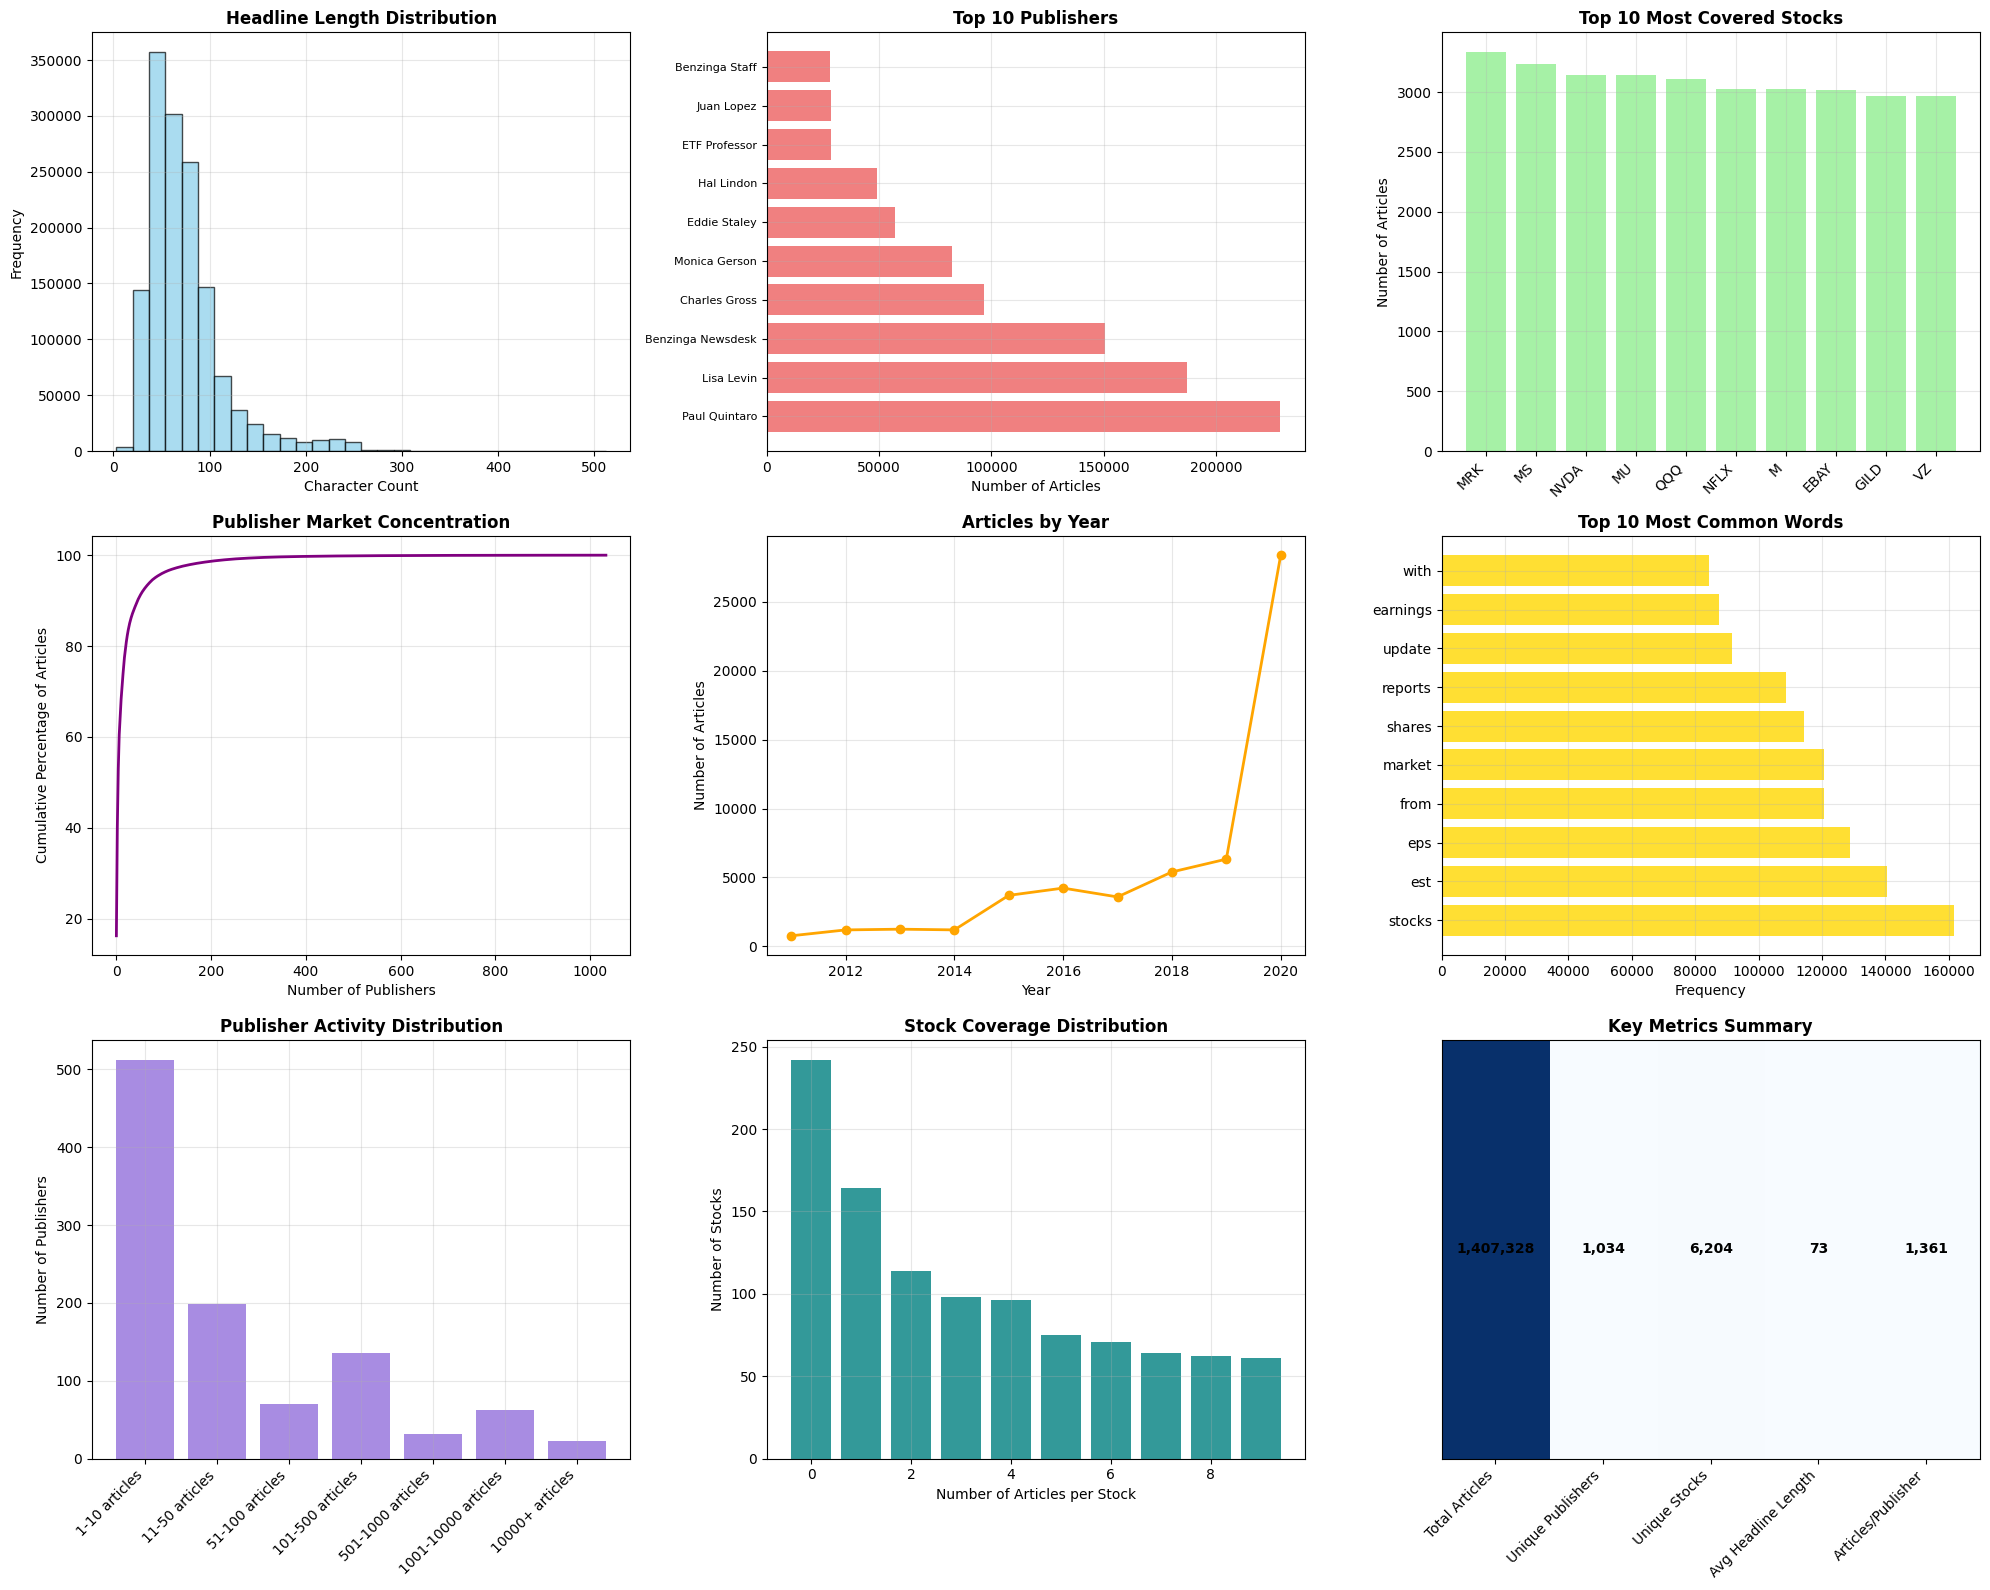

Comprehensive visualizations generated successfully!


In [26]:
# Create comprehensive visualizations
fig = plt.figure(figsize=(20, 16))

# 1. Headline length distribution
ax1 = plt.subplot(3, 3, 1)
ax1.hist(headline_lengths, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax1.set_title('Headline Length Distribution', fontweight='bold')
ax1.set_xlabel('Character Count')
ax1.set_ylabel('Frequency')
ax1.grid(True, alpha=0.3)

# 2. Top publishers
ax2 = plt.subplot(3, 3, 2)
top_10_pubs = publisher_counts.head(10)
bars = ax2.barh(range(len(top_10_pubs)), top_10_pubs.values, color='lightcoral')
ax2.set_yticks(range(len(top_10_pubs)))
ax2.set_yticklabels(top_10_pubs.index, fontsize=8)
ax2.set_xlabel('Number of Articles')
ax2.set_title('Top 10 Publishers', fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Top stocks
ax3 = plt.subplot(3, 3, 3)
top_10_stocks = stock_counts.head(10)
ax3.bar(range(len(top_10_stocks)), top_10_stocks.values, color='lightgreen', alpha=0.8)
ax3.set_xticks(range(len(top_10_stocks)))
ax3.set_xticklabels(top_10_stocks.index, rotation=45, ha='right')
ax3.set_ylabel('Number of Articles')
ax3.set_title('Top 10 Most Covered Stocks', fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4. Publisher concentration
ax4 = plt.subplot(3, 3, 4)
cumulative_pct = (publisher_counts.sort_values(ascending=False).cumsum() / len(df) * 100)
ax4.plot(range(len(cumulative_pct)), cumulative_pct, color='purple', linewidth=2)
ax4.set_xlabel('Number of Publishers')
ax4.set_ylabel('Cumulative Percentage of Articles')
ax4.set_title('Publisher Market Concentration', fontweight='bold')
ax4.grid(True, alpha=0.3)

# 5. Temporal trends (if available)
ax5 = plt.subplot(3, 3, 5)
if temporal_analysis and 'articles_by_year' in temporal_analysis:
    years = list(temporal_analysis['articles_by_year'].keys())
    counts = list(temporal_analysis['articles_by_year'].values())
    ax5.plot(years, counts, marker='o', linewidth=2, markersize=6, color='orange')
    ax5.set_xlabel('Year')
    ax5.set_ylabel('Number of Articles')
    ax5.set_title('Articles by Year', fontweight='bold')
    ax5.grid(True, alpha=0.3)
else:
    ax5.text(0.5, 0.5, 'Temporal data\nnot available', ha='center', va='center', transform=ax5.transAxes)
    ax5.set_title('Articles by Year', fontweight='bold')

# 6. Word frequency (if available)
ax6 = plt.subplot(3, 3, 6)
if word_analysis and 'top_words' in word_analysis:
    top_words = list(word_analysis['top_words'].items())[:10]
    words = [item[0] for item in top_words]
    counts = [item[1] for item in top_words]
    ax6.barh(range(len(words)), counts, color='gold', alpha=0.8)
    ax6.set_yticks(range(len(words)))
    ax6.set_yticklabels(words)
    ax6.set_xlabel('Frequency')
    ax6.set_title('Top 10 Most Common Words', fontweight='bold')
    ax6.grid(True, alpha=0.3)
else:
    ax6.text(0.5, 0.5, 'Word frequency\nnot available', ha='center', va='center', transform=ax6.transAxes)
    ax6.set_title('Top 10 Most Common Words', fontweight='bold')

# 7. Publisher activity distribution
ax7 = plt.subplot(3, 3, 7)
activity_bins = publisher_analysis['activity_bins']
categories = list(activity_bins.keys())
counts = list(activity_bins.values())
ax7.bar(range(len(categories)), counts, color='mediumpurple', alpha=0.8)
ax7.set_xticks(range(len(categories)))
ax7.set_xticklabels(categories, rotation=45, ha='right')
ax7.set_ylabel('Number of Publishers')
ax7.set_title('Publisher Activity Distribution', fontweight='bold')
ax7.grid(True, alpha=0.3)

# 8. Stock coverage distribution
ax8 = plt.subplot(3, 3, 8)
stock_coverage = stock_counts.value_counts().head(10)
ax8.bar(range(len(stock_coverage)), stock_coverage.values, color='teal', alpha=0.8)
ax8.set_xlabel('Number of Articles per Stock')
ax8.set_ylabel('Number of Stocks')
ax8.set_title('Stock Coverage Distribution', fontweight='bold')
ax8.grid(True, alpha=0.3)

# 9. Summary statistics heatmap
ax9 = plt.subplot(3, 3, 9)
summary_data = {
    'Total Articles': [len(df)],
    'Unique Publishers': [df['publisher'].nunique()],
    'Unique Stocks': [df['stock'].nunique()],
    'Avg Headline Length': [headline_lengths.mean()],
    'Articles/Publisher': [len(df) / df['publisher'].nunique()]
}
summary_df = pd.DataFrame(summary_data)
im = ax9.imshow(summary_df.values, cmap='Blues', aspect='auto')
ax9.set_xticks(range(len(summary_df.columns)))
ax9.set_xticklabels(summary_df.columns, rotation=45, ha='right')
ax9.set_yticks([])
ax9.set_title('Key Metrics Summary', fontweight='bold')

# Add values to heatmap
for i, col in enumerate(summary_df.columns):
    ax9.text(i, 0, f'{summary_df[col].iloc[0]:,.0f}', ha='center', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Comprehensive visualizations generated successfully!")

## 10. Summary Report

In [27]:
# Generate comprehensive summary report
print("=" * 60)
print("COMPREHENSIVE DATASET ANALYSIS SUMMARY")
print("=" * 60)

# Dataset Overview
print("\n📊 DATASET OVERVIEW:")
print(f"   • Total Articles: {len(df):,}")
print(f"   • Unique Publishers: {df['publisher'].nunique():,}")
print(f"   • Unique Stocks: {df['stock'].nunique():,}")
print(f"   • Date Range: {temporal_analysis.get('date_range', {}).get('start', 'N/A')} to {temporal_analysis.get('date_range', {}).get('end', 'N/A')}")

# Headline Statistics
print("\n📝 HEADLINE STATISTICS:")
print(f"   • Average Length: {headline_lengths.mean():.1f} characters")
print(f"   • Median Length: {headline_lengths.median():.1f} characters")
print(f"   • Range: {headline_lengths.min()} - {headline_lengths.max()} characters")

# Publisher Insights
print("\n🏢 PUBLISHER INSIGHTS:")
print(f"   • Market Concentration (Top 5): {publisher_analysis['concentration_ratio']['top_5']:.1f}%")
print(f"   • Average Articles per Publisher: {basic_stats['publisher_stats']['avg_articles_per_publisher']:.1f}")
print(f"   • Most Active Publisher: {top_publishers.index[0]} ({top_publishers.iloc[0]:,} articles)")

# Stock Coverage
print("\n📈 STOCK COVERAGE:")
print(f"   • Stocks with Single Article: {stock_analysis['stocks_with_single_article']:,}")
print(f"   • Most Covered Stock: {top_stocks.index[0]} ({top_stocks.iloc[0]:,} articles)")

# Temporal Patterns
if temporal_analysis and 'articles_by_year' in temporal_analysis:
    print("\n📅 TEMPORAL PATTERNS:")
    latest_year = max(temporal_analysis['articles_by_year'].keys())
    print(f"   • Most Active Year: {int(latest_year)} ({temporal_analysis['articles_by_year'][latest_year]:,} articles)")
    if 'articles_by_day_of_week' in temporal_analysis:
        busiest_day = max(temporal_analysis['articles_by_day_of_week'], key=temporal_analysis['articles_by_day_of_week'].get)
        print(f"   • Busiest Day: {busiest_day} ({temporal_analysis['articles_by_day_of_week'][busiest_day]:,} articles)")

# Word Analysis
if word_analysis and 'top_words' in word_analysis:
    print("\n🔤 WORD ANALYSIS:")
    print(f"   • Total Words Processed: {word_analysis['total_words']:,}")
    print(f"   • Unique Words: {word_analysis['unique_words']:,}")
    print(f"   • Most Common Word: '{list(word_analysis['top_words'].keys())[0]}' ({list(word_analysis['top_words'].values())[0]:,} occurrences)")

print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)

COMPREHENSIVE DATASET ANALYSIS SUMMARY

📊 DATASET OVERVIEW:
   • Total Articles: 1,407,328
   • Unique Publishers: 1,034
   • Unique Stocks: 6,204
   • Date Range: 2011-04-27 to 2020-06-11

📝 HEADLINE STATISTICS:
   • Average Length: 73.1 characters
   • Median Length: 64.0 characters
   • Range: 3 - 512 characters

🏢 PUBLISHER INSIGHTS:
   • Market Concentration (Top 5): 52.9%
   • Average Articles per Publisher: 1361.1
   • Most Active Publisher: Paul Quintaro (228,373 articles)

📈 STOCK COVERAGE:
   • Stocks with Single Article: 242
   • Most Covered Stock: MRK (3,333 articles)

📅 TEMPORAL PATTERNS:
   • Most Active Year: 2020 (28,392 articles)
   • Busiest Day: Thursday (12,688 articles)

🔤 WORD ANALYSIS:
   • Total Words Processed: 11,656,065
   • Unique Words: 92,619
   • Most Common Word: 'stocks' (161,776 occurrences)

ANALYSIS COMPLETE
